In [1]:
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions
from tensorflow.keras.optimizers import Adam

2026-02-01 10:31:39.672198: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=44)

In [3]:
X.shape, y.shape

((100, 2), (100,))

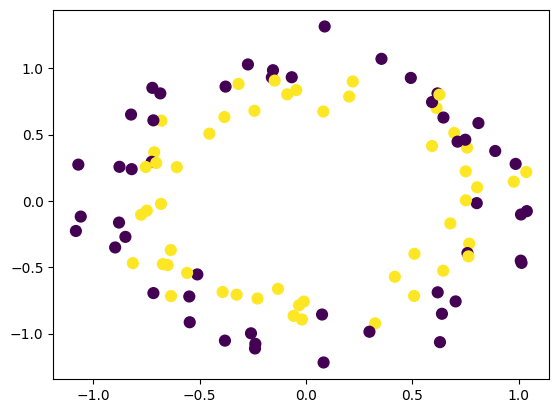

In [4]:
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, s=60)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)

In [6]:
tf.keras.backend.clear_session()
model_without_do = Sequential()

In [7]:
model_without_do.add(Input(shape=(2,)))
model_without_do.add(Dense(128, activation='relu'))
model_without_do.add(Dense(128, activation='relu'))
model_without_do.add(Dense(1, activation='sigmoid'))

In [8]:
OPT_WITHOUT_DO = Adam(learning_rate=0.1)

In [9]:
model_without_do.compile(loss='binary_crossentropy', optimizer=OPT_WITHOUT_DO, metrics=['accuracy'])

In [10]:
history = model_without_do.fit(X_train, y_train, epochs=500, validation_split=0.5)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 0.4250 - loss: 1.2514 - val_accuracy: 0.4750 - val_loss: 0.8283
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6000 - loss: 0.6306 - val_accuracy: 0.5000 - val_loss: 0.8005
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 0.9960 - val_accuracy: 0.5250 - val_loss: 0.7267
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4500 - loss: 0.7717 - val_accuracy: 0.4250 - val_loss: 0.7778
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6250 - loss: 0.7287 - val_accuracy: 0.4750 - val_loss: 0.7413
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5750 - loss: 0.6414 - val_accuracy: 0.4250 - val_loss: 0.6740
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6500 - loss: 0.6207 - val_accuracy: 0.5750 - val_loss: 0.6626
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6000 - loss: 0.6296 - val_accuracy: 0.6000 - val_loss

In [11]:
y_pred = np.where(model_without_do.predict(X_test)>=0.5, 1, 0)
y_pred[:5], y_test[:5]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


(array([[1],
        [0],
        [1],
        [1],
        [0]]),
 array([0, 0, 1, 1, 1]))

In [12]:
accuracy_score(y_test, y_pred)* 100

60.0

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

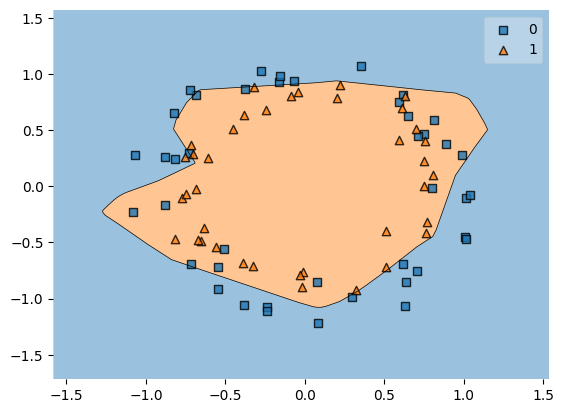

In [13]:
plot_decision_regions(X_train, y_train, clf=model_without_do, zoom_factor=2)

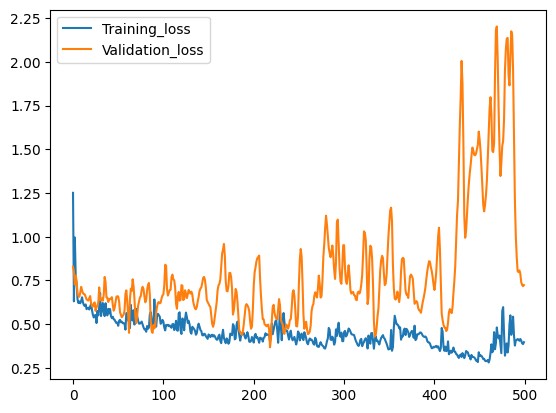

In [14]:
plt.plot(history.history['loss'], label='Training_loss')
plt.plot(history.history['val_loss'], label='Validation_loss')
plt.legend()
plt.show()

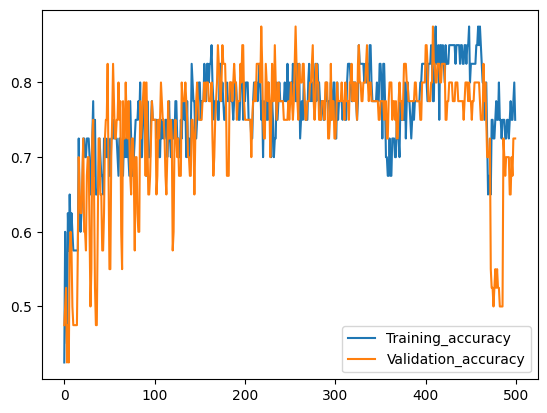

In [15]:
plt.plot(history.history['accuracy'], label='Training_accuracy')
plt.plot(history.history['val_accuracy'], label='Validation_accuracy')
plt.legend()
plt.show()

## now with dropouts:

In [16]:
OPT_WITH_DO = Adam(learning_rate=0.01)

In [17]:
tf.keras.backend.clear_session()
model_with_do = Sequential()

In [18]:
model_with_do.add(Input(shape=(2,)))
model_with_do.add(Dropout(0.3))
model_with_do.add(Dense(128, activation='relu'))
model_with_do.add(Dropout(0.3))
model_with_do.add(Dense(128, activation='relu'))
model_with_do.add(Dropout(0.3))
model_with_do.add(Dense(1, activation='sigmoid'))

In [19]:
model_with_do.compile(loss='binary_crossentropy', optimizer=OPT_WITH_DO, metrics=['accuracy'])

In [20]:
history = model_with_do.fit(X_train, y_train, validation_split=0.5, epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - accuracy: 0.4750 - loss: 0.7160 - val_accuracy: 0.4750 - val_loss: 0.7057
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5250 - loss: 0.6544 - val_accuracy: 0.4750 - val_loss: 0.7412
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6000 - loss: 0.6336 - val_accuracy: 0.4750 - val_loss: 0.7675
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5750 - loss: 0.6843 - val_accuracy: 0.4750 - val_loss: 0.7780
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.5750 - loss: 0.6918 - val_accuracy: 0.3500 - val_loss: 0.7581
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6250 - loss: 0.6808 - val_accuracy: 0.3750 - val_loss: 0.7409
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4250 - loss: 0.7400 - val_accuracy: 0.4750 - val_loss: 0.7261
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5500 - loss: 0.6532 - val_accuracy: 0.5500 - val_lo

In [ ]:
y_pred = np.where(model_with_do.predict(X_test)>=0.5, 1, 0)
y_pred[:5], y_test[:5]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


(array([[1],
        [1],
        [1],
        [1],
        [1]]),
 array([0, 0, 1, 1, 1]))

In [22]:
accuracy_score(y_test, y_pred)* 100

65.0

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


<Axes: >

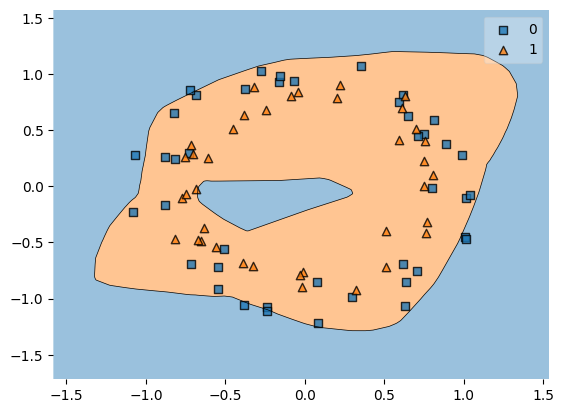

In [23]:
plot_decision_regions(X_train, y_train, clf=model_with_do, zoom_factor=2)

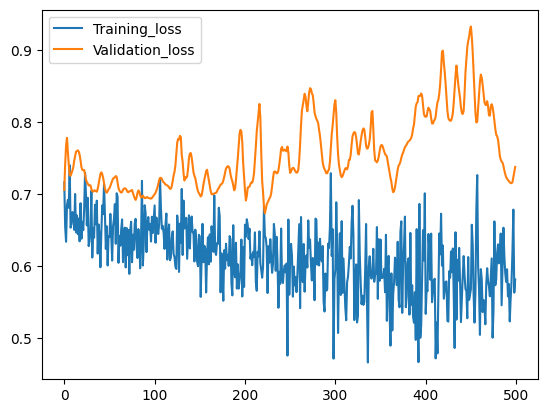

In [24]:
plt.plot(history.history['loss'], label='Training_loss')
plt.plot(history.history['val_loss'], label='Validation_loss')
plt.legend()
plt.show()

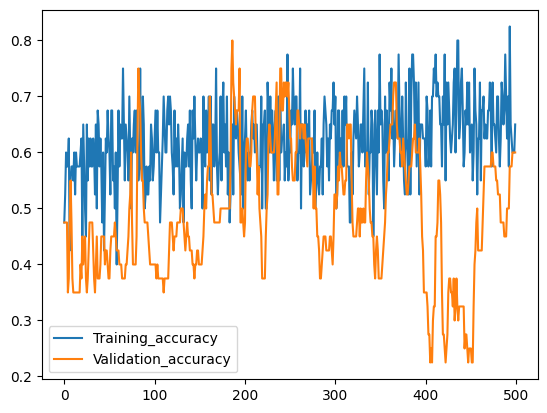

In [25]:
plt.plot(history.history['accuracy'], label='Training_accuracy')
plt.plot(history.history['val_accuracy'], label='Validation_accuracy')
plt.legend()
plt.show()

so above we can see it reduces overfitting and increases accuracy